Disclaimer: Use this notebook as a reference on how to visualize the plots, rather than ground truth

## Absolute losses


Loading: .\out_config_tiedw_identity_01wd_1_4e-3lr_2e-5\eval_val_tensor.pt
Loading: .\out_config_tiedw_identity_01wd_1_6e-3lr_2e-5\eval_val_tensor.pt
Loading: .\out_config_tiedw_identity_larger_mlp_01wd_1_8e-3lr_2e-5\eval_val_tensor.pt
Loading: .\out_config_tiedw_identity_larger_mlp_01wd_2_2e-3lr_2e-5\eval_val_tensor.pt
Loading: .\out_config_tiedw_identity_larger_mlp_01wd_2e-3lr_2e-5\eval_val_tensor.pt
Loading: .\out_config_tiedw_original\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_005wd\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_mlp_4_33_times\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_mlp_4_5_times\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_mlp_4_625_times\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_mlp_4_75_times\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_mlp_4_75_times_lrscaled\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_smaller_mlp\eval_val_tensor.pt
Loading: .\out_config_tiedw_original_smaller

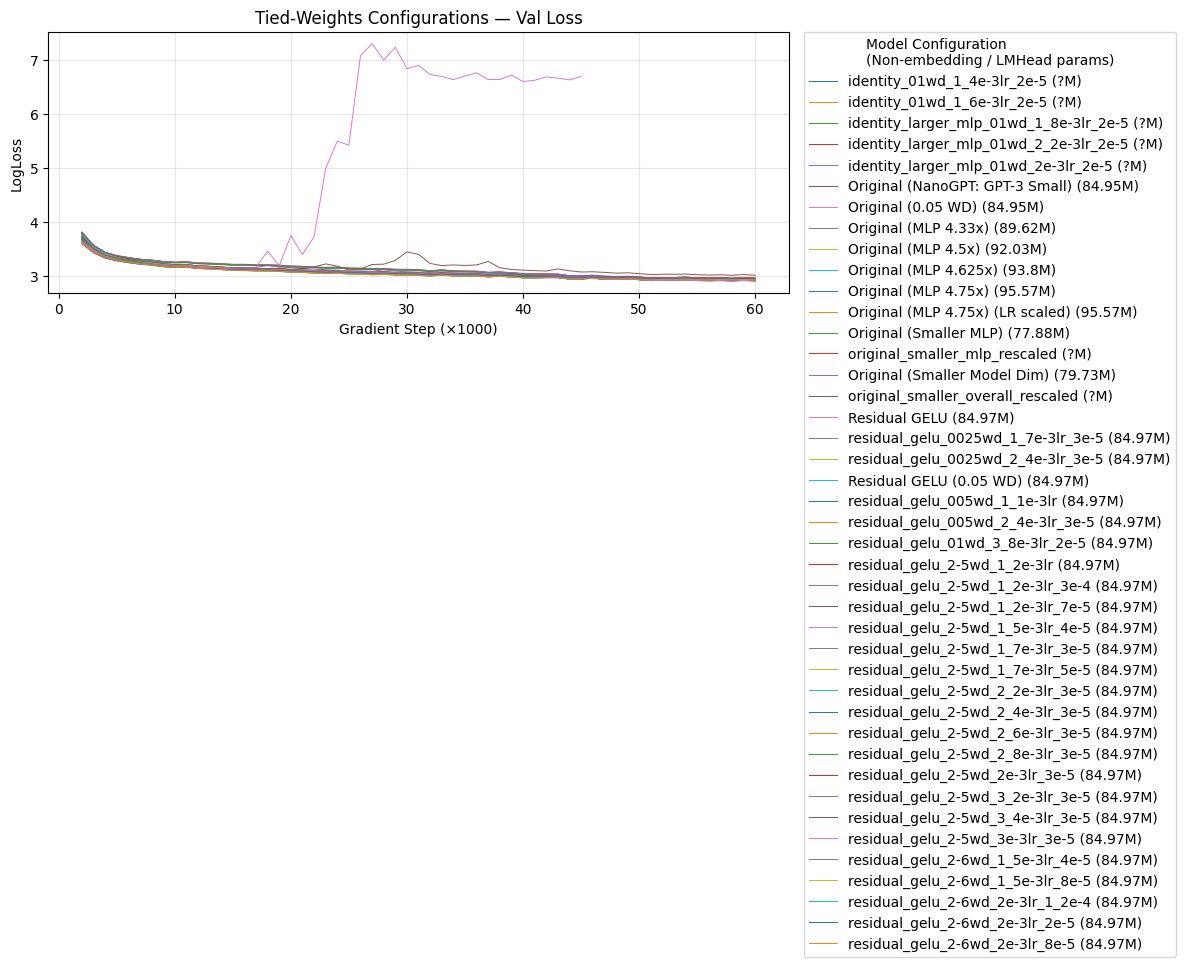

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import torch

# -------------------- CONFIG --------------------
start_num = 2
end_num = 61
plot_part = "val"  # "train" or "val"
mode = "tiedw"

base_dir = "."

# -------------------- FOLDER DISCOVERY --------------------
pattern = re.compile(rf"^out_config_{mode}_.+")
folders = [
    folder for folder in os.listdir(base_dir)
    if pattern.match(folder)
    and os.path.isdir(os.path.join(base_dir, folder))
]

folders.sort()

# -------------------- NAMING --------------------
name_map = {
    "original": "Original (NanoGPT: GPT-3 Small)",
    "identity": "W_Q = Identity",
    "identity_larger_mlp": "W_Q = Identity (Larger MLP)",
    "original_smaller_mlp": "Original (Smaller MLP)",
    "original_smaller_overall": "Original (Smaller Model Dim)",
    "residual_gelu": "Residual GELU",
    "original_005wd": "Original (0.05 WD)",
    "residual_gelu_005wd": "Residual GELU (0.05 WD)",
}

# -------------------- PARAM COUNTS --------------------
D_MODEL = 768
LAYERS = 12
BASE_PARAMS = 84.95  # GPT‑3 Small (Expansion=4)

adjusted_params = round(BASE_PARAMS + (D_MODEL * LAYERS * 2) / 1e6, 2)

param_counts = {
    "original": BASE_PARAMS,
    "identity": 77.88,
    "identity_larger_mlp": BASE_PARAMS,
    "original_smaller_mlp": 77.88,
    "original_smaller_overall": 79.73,
    "residual_gelu": adjusted_params,
    "original_005wd": BASE_PARAMS,
    "residual_gelu_005wd": adjusted_params,
}

def get_params_and_name(key):
    name = name_map.get(key, key)

    if "residual_gelu" in key and key not in param_counts:
        return name, adjusted_params

    if key in param_counts:
        return name, param_counts[key]

    # Dynamic MLP scaling
    match = re.search(r"mlp_([\d_]+)_times", key)
    if match:
        ratio = float(match.group(1).replace("_", "."))
        delta_params = (2 * ratio - 8) * (D_MODEL ** 2) * LAYERS
        new_total = BASE_PARAMS + delta_params / 1e6
        return f"Original (MLP {ratio}x)", round(new_total, 2)

    return name, "?"

# -------------------- PLOTTING --------------------
plt.figure(figsize=(12, 7))

for folder in folders:
    full_path = os.path.join(base_dir, folder)
    file_path = os.path.join(full_path, f"eval_{plot_part}_tensor.pt")

    if not os.path.exists(file_path):
        continue

    print(f"Loading: {file_path}")
    data = torch.load(file_path, map_location="cpu")

    current_end = min(end_num, data.size(0))
    if current_end <= start_num:
        continue

    series = pd.Series(data[start_num:current_end, 1].numpy())
    series = series.replace(0, np.nan)

    # -------------------- MODEL KEY HANDLING --------------------
    raw_key = folder.split(f"{mode}_")[-1]

    is_lrscaled = raw_key.endswith("_lrscaled")
    base_key = re.sub(r"_lrscaled$", "", raw_key)

    readable_name, p_count = get_params_and_name(base_key)
    lr_suffix = " (LR scaled)" if is_lrscaled else ""

    final_label = f"{readable_name}{lr_suffix} ({p_count}M)"

    x_values = np.arange(start_num, start_num + len(series))

    if True: #series.min() > 0 and series.max() < 5.50 :#and "original" in full_path :
        plt.plot(x_values, series.tolist(), label=final_label,linewidth = 0.7)

# -------------------- FINAL TOUCHES --------------------
plt.legend(
    title="Model Configuration\n(Non‑embedding / LMHead params)", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0
)
plt.title(f"Tied‑Weights Configurations — {plot_part.capitalize()} Loss")
#plt.ylim(2.9, 2.93)
plt.xlabel("Gradient Step (×1000)")
plt.ylabel("LogLoss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Relative losses comparison (wrt baseline)

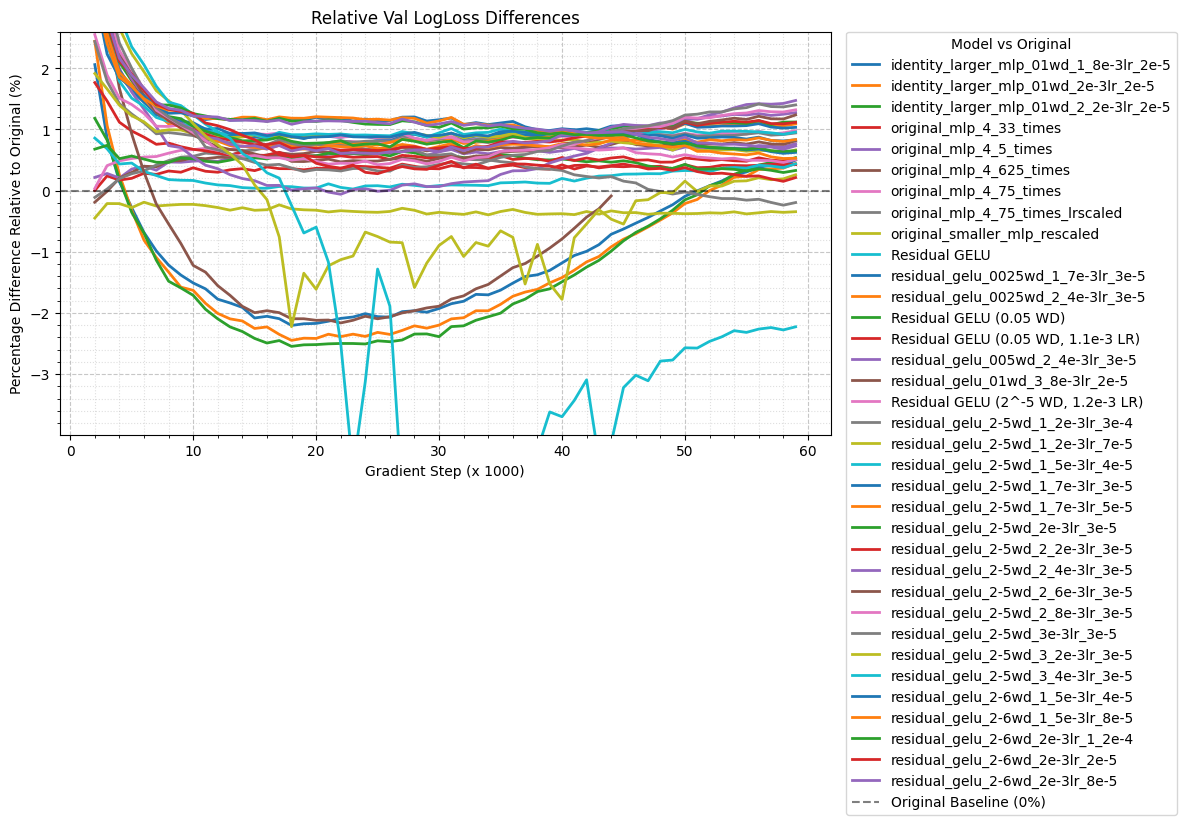

<Figure size 640x480 with 0 Axes>

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

start_num = 2
end_num = 61

plot_part = "val"  # "val" or "val"
mode = "tiedw" 

# Define folders programmatically
base_dir = "."
folders = [folder for folder in os.listdir(base_dir) if folder.startswith(f"out_config_{mode}_") and os.path.isdir(os.path.join(base_dir, folder))]

folder_dict = {}

# --- 1. Concise Names ---
name_map = {
    "original": "Original (NanoGPT: GPT-3 Small)",
    "identity": "W_Q = Identity",
    "identity_larger_mlp": "W_Q = Identity (Larger MLP)",
    "original_smaller_mlp": "Original (Smaller MLP)",
    "original_smaller_overall": "Original (Smaller Model Dim)",
    "residual_gelu": "Residual GELU",
    "original_005wd": "Original (0.05 WD)",
    "residual_gelu_005wd": "Residual GELU (0.05 WD)",
    "residual_gelu_005wd_1_1e-3lr": "Residual GELU (0.05 WD, 1.1e-3 LR)",
    "residual_gelu_2-5wd_1_2e-3lr": "Residual GELU (2^-5 WD, 1.2e-3 LR)",
}


# --- Load Data First ---
for folder in folders:
    full_path = os.path.join(base_dir, folder)
    file_path = os.path.join(full_path, f"eval_{plot_part}_tensor.pt")
    
    if not os.path.exists(file_path):
        continue

    # Load and process data
    data = torch.load(file_path, map_location=torch.device('cpu'))
    # CHANGE: Replace 0 with NaN to treat them as uncalculated/missing values
    series = pd.Series(data[start_num:end_num, 1].cpu().numpy()).replace(0, np.nan)
    
    # Identify model
    model_key = folder.split(f"{mode}_")[-1]
    folder_dict[model_key] = series

# --- 2. Plotting Relative Differences ---
plt.figure(figsize=(12, 7))

# Ensure baseline exists
if "original" in folder_dict:
    baseline_series = folder_dict["original"]
    
    for key, series in folder_dict.items():
        if key == "original":
            continue 

        # --- RESTORED FILTER (WITH ALL COMMENTED FRAGMENTS) ---
        # CHANGE: Removed "series.min() > 0" check. 
        # By using NaNs, .max() and .min() ignore uncalculated values.
        #Smaller
        if (series.max() < 20) and \
        (("original" in name_map.get(key, key)) or \
         "identity" in name_map.get(key, key)or "original" in name_map.get(key, key))\
        and ("mlp" in name_map.get(key, key) or "2-5" in name_map.get(key, key)) or "gelu" in name_map.get(key, key).lower():
            

            rel_diff = ((baseline_series.subtract(series, fill_value=np.nan)) / baseline_series) * 100
            
            # Construct Label
            name = name_map.get(key, key)
            label = f"{name}"
            
            x_values = np.arange(start_num, start_num + len(rel_diff))
            plt.plot(x_values, rel_diff.tolist(), label=label, linewidth=2)

    # Add Reference Line at 0%
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label="Original Baseline (0%)")

plt.legend(
    title="Model vs Original", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0
)
plt.title(f"Relative {plot_part.capitalize()} LogLoss Differences")
plt.xlabel("Gradient Step (x 1000)")
plt.ylabel("Percentage Difference Relative to Original (%)")
plt.ylim((-3.99,2.6))
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
plt.savefig("relative val logloss differences")

## Paper Style plots
Requires the specific configs

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# --- Configuration ---
start_num = 5
end_num = 61
baseline_key = "original"
baseline_lr_max = 6.0e-4
baseline_lr_min = 6.0e-5

# Config used as the "best run" in the absolute-loss comparison and for the training curve in the plot
best_key = "res_gelu_01wd_3.6e-3"

folders = {
    "original": "out_config_tiedw_original/",

    # Residual GELU runs (best HP configs from the full sweep)
    "res_gelu_01wd_3.6e-3":   "out_config_tiedw_residual_gelu_01wd_3_6e-3lr_2e-5/",
    "res_gelu_01wd_4.0e-3":   "out_config_tiedw_residual_gelu_01wd_4_0e-3lr_1e-5/",
    "res_gelu_005wd_2.4e-3":  "out_config_tiedw_residual_gelu_005wd_2_4e-3lr_3e-5/",

    # Widened MLP controls
    "orig_mlp_4.75_lrscaled": "out_config_tiedw_original_mlp_4_75_times_lrscaled/",
    "orig_mlp_4.75":          "out_config_tiedw_original_mlp_4_75_times/",
}

models = {
    # Residual GELU runs (best HP configs from the full sweep)
    "res_gelu_01wd_3.6e-3": {
        "name":   r"Res GELU ($\lambda=0.10$, $\eta_{\max}=3.6{\cdot}10^{-3}$)",
        "color":  "#3030CE",
        "lr_max": 3.6e-3,
        "lr_min": 2.0e-5,
    },
    "res_gelu_01wd_4.0e-3": {
        "name":   r"Res GELU ($\lambda=0.10$, $\eta_{\max}=4.0{\cdot}10^{-3}$)",
        "color":  "#249C24",
        "lr_max": 4.0e-3,
        "lr_min": 1.0e-5,
    },
    "res_gelu_005wd_2.4e-3": {
        "name":   r"Res GELU ($\lambda=0.05$, $\eta_{\max}=2.4{\cdot}10^{-3}$)",
        "color":  "#CE30CE",
        "lr_max": 2.4e-3,
        "lr_min": 3.0e-5,
    },

    # Widened MLP controls
    "orig_mlp_4.75_lrscaled": {
        "name":   r"MLP $4.75d$ ($\eta = \eta_{\mathrm{base}}/\sqrt{1.125}$)",
        "color":  "#249C9C",
        "lr_max": 6.0e-4 / 1.125 ** 0.5,
        "lr_min": 6.0e-5 / 1.125 ** 0.5,
    },
    "orig_mlp_4.75": {
        "name":   r"MLP $4.75d$ ($\eta = \eta_{\mathrm{base}}$)",
        "color":  "#A58526",
        "lr_max": 6.0e-4,
        "lr_min": 6.0e-5,
    },
}

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'legend.frameon': False,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


# === Final val loss table at step ~end_num ===

base_full = torch.load(os.path.join(folders[baseline_key], "eval_val_tensor.pt"), map_location=torch.device('cpu') )
final_idx = min(end_num - 1, len(base_full) - 1)
base_loss = float(base_full[final_idx, 1].cpu())
base_ppx = float(np.exp(base_loss))


# === Table 1 (headline): absolute log-loss for baseline vs 4.75 MLP vs best run ===

absolute_rows = [
    ("baseline (original)", baseline_lr_max, baseline_lr_min, base_loss),
]
for k in ("orig_mlp_4.75_lrscaled", "orig_mlp_4.75", best_key):
    var_full = torch.load(os.path.join(folders[k], "eval_val_tensor.pt"), map_location=torch.device('cpu') )
    idx = min(end_num - 1, len(var_full) - 1)
    absolute_rows.append((
        f"{k}{' (best)' if k == best_key else ''}",
        models[k]["lr_max"],
        models[k]["lr_min"],
        float(var_full[idx, 1].cpu()),
    ))

abs_header = f" {'Configuration':<32} {'LR max':>9} {'LR min':>9} {'Val log-loss':>14}"
abs_sep = "-" * len(abs_header)
abs_edge = "=" * len(abs_header)
print(abs_edge)
print(" Absolute log-loss (headline comparison)")
print(abs_edge)
print(abs_header)
print(abs_sep)
for name, lr_max, lr_min, val in absolute_rows:
    print(f" {name:<32} {lr_max:>9.2e} {lr_min:>9.2e} {val:>14.4f}")
print(abs_edge)
print()


# === Table 2 (sweep): relative difference vs baseline for all tested configs ===

rel_header = f" {'Configuration':<32} {'LR max':>9} {'LR min':>9} {'Val loss':>10} {'Δ log-loss':>12} {'Δ PPX':>10}"
rel_sep = "-" * len(rel_header)
rel_edge = "=" * len(rel_header)
print(rel_edge)
print(" Relative improvement over baseline (full sweep)")
print(rel_edge)
print(rel_header)
print(rel_sep)
print(f" {'baseline (original)':<32} {baseline_lr_max:>9.2e} {baseline_lr_min:>9.2e} {base_loss:>10.4f}   {'— (ref.)':>10}   {'— (ref.)':>8}")
print(rel_sep)

for key in models:
    path = os.path.join(folders[key], "eval_val_tensor.pt")
    lr_max = models[key]["lr_max"]
    lr_min = models[key]["lr_min"]
    if not os.path.exists(path):
        print(f" {key:<32} {lr_max:>9.2e} {lr_min:>9.2e} {'—':>10}   {'(no data)':>10}   {'':>8}")
        continue
    var_full = torch.load(path, map_location=torch.device('cpu') )
    idx = min(end_num - 1, len(var_full) - 1)
    var_loss = float(var_full[idx, 1].cpu())
    var_ppx = float(np.exp(var_loss))
    rel_delta_ll  = (base_loss - var_loss) / base_loss * 100.0  # + = improvement
    rel_delta_ppx = (base_ppx  - var_ppx ) / base_ppx  * 100.0
    print(f" {key:<32} {lr_max:>9.2e} {lr_min:>9.2e} {var_loss:>10.4f}   {rel_delta_ll:>+9.2f}%   {rel_delta_ppx:>+7.2f}%")

print(rel_edge)
print(f"  (final index: {final_idx}; step ≈ {final_idx + 1}k)\n")


# === Combined stacked figure: top = absolute log-loss, bottom = relative improvement ===
# Drop-in replacement for the paper's existing iclr_stacked.pdf.
# Top panel:    baseline + both 4.75d MLP variants + best Res GELU.
# Bottom panel: all Res GELU + MLP variants as relative improvement vs baseline.
# Solid: validation. Dashed: training (best run only, paper Figure 1 style).

abs_configs = [
    (baseline_key,              "Baseline (original)",                                 "#333333"),
    ("orig_mlp_4.75_lrscaled",  models["orig_mlp_4.75_lrscaled"]["name"],              models["orig_mlp_4.75_lrscaled"]["color"]),
    ("orig_mlp_4.75",           models["orig_mlp_4.75"]["name"],                       models["orig_mlp_4.75"]["color"]),
    (best_key,                  models[best_key]["name"],                              models[best_key]["color"]),
]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 8), dpi=150, sharex=True)

# --- Top panel: absolute validation log-loss ---
for plot_part in ("train", "val"):
    for key, _name, color in abs_configs:
        if plot_part == "train" and key != best_key:  # train curve only for best run
            continue
        path = os.path.join(folders[key], f"eval_{plot_part}_tensor.pt")
        if not os.path.exists(path):
            continue
        tensor = torch.load(path, map_location=torch.device('cpu') )
        max_len = min(len(tensor), end_num)
        raw = tensor[start_num:max_len, 1].cpu().numpy()
        x_values = np.arange(start_num, start_num + len(raw))
        ls, lw, alpha = ("-", 1.8, 1.0) if plot_part == "val" else ("--", 1.2, 0.6)
        ax_top.plot(x_values, raw, color=color, linestyle=ls, linewidth=lw, alpha=alpha)

ax_top.set_ylabel("Validation Log-Loss", fontsize=11)
ax_top.grid(axis='y', linestyle='--', alpha=0.45)

# --- Bottom panel: relative log-loss improvement over baseline ---
for plot_part in ("train", "val"):
    base_path = os.path.join(folders[baseline_key], f"eval_{plot_part}_tensor.pt")
    if not os.path.exists(base_path):
        continue
    base_full_data = torch.load(base_path, map_location=torch.device('cpu') )

    for key, folder in folders.items():
        if key == baseline_key:
            continue
        if plot_part == "train" and key != best_key:  # train curve only for best run
            continue
        variant_path = os.path.join(folder, f"eval_{plot_part}_tensor.pt")
        if not os.path.exists(variant_path):
            continue

        variant_full_data = torch.load(variant_path, map_location=torch.device('cpu') )
        max_len = min(len(base_full_data), len(variant_full_data), end_num)
        base_raw = base_full_data[start_num:max_len, 1].cpu().numpy()
        var_raw  = variant_full_data[start_num:max_len, 1].cpu().numpy()
        data = (base_raw - var_raw) / base_raw * 100

        x_values = np.arange(start_num, start_num + len(data))
        ls, lw, alpha = ("-", 1.8, 1.0) if plot_part == "val" else ("--", 1.2, 0.6)
        ax_bot.plot(x_values, data, color=models[key]['color'],
                    linestyle=ls, linewidth=lw, alpha=alpha)

ax_bot.axhline(y=0, color='#999999', linestyle=':', linewidth=1.2, zorder=0)
ax_bot.set_ylim(top=3, bottom=-3)
ax_bot.set_xlabel(r"Gradient Steps ($\times 10^3$)", fontsize=11)
ax_bot.set_ylabel(r"Rel. Log-Loss Improvement (%)", fontsize=11)
ax_bot.set_xlim(start_num, end_num)
ax_bot.grid(axis='y', linestyle='--', alpha=0.45)

# --- Shared legend beneath both panels ---
# Baseline appears as a dark-gray line in the top panel and as the y=0 dotted reference in the bottom panel.
model_handles = [Patch(facecolor="#333333", label="Baseline (original)")]
model_handles += [Patch(facecolor=m['color'], label=m['name']) for m in models.values()]
style_handles = [
    Line2D([0], [0], color='#666666', linestyle='-',  lw=1.8,            label='Validation'),
    Line2D([0], [0], color='#666666', linestyle='--', lw=1.2, alpha=0.6, label='Train (best)'),
]
fig.legend(handles=model_handles + style_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8,
           handlelength=1.6, handletextpad=0.5, columnspacing=1.4, borderaxespad=0.2)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # reserve bottom strip for the legend
plt.savefig('iclr_stacked.pdf', bbox_inches='tight')
plt.show()